**Goal:** watch a 94%-accurate model turn out to miss two-thirds of the cases that
matter -- then measure it honestly. You will read a confusion matrix, compute
precision/recall/F1, move the decision threshold to trade one for the other, draw an
ROC curve, and finish with the regression metrics. Pairs with the concept note
[Evaluation Metrics](l11_concept_evaluation_metrics.qmd).

> **Previously:** L10 -- Regularization & Model/Feature Selection  |  **Next:** L12 -- Decision Trees & Bagging (Unit IV)

> This page is the read-only view. To run the lab, open the notebook
> (`l11_lab_evaluation_metrics.ipynb`) -- in Colab via the badge on the concept page,
> or locally.

## Scenario

A field team screens coqui for a rare skin disease from a handful of quick field
measurements. The disease is **uncommon** -- under 1 frog in 10 is infected -- and
**missing a sick frog (a false negative) is far worse than a false alarm**: an
untreated carrier spreads it. Build a classifier, then find out what its headline
accuracy is really hiding.

The data is **synthetic** (a fixed seed, identical for everyone) with *fictionalized
but plausible* values -- the framing is real, the numbers are not field measurements.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the
second imports, seeds the generator, builds the imbalanced data, and splits it.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy, pandas and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# ~8% of frogs are infected (the positive class) -- a deliberately imbalanced screen.
X, y = make_classification(n_samples=1000, n_features=8, n_informative=4, n_redundant=1,
                           weights=[0.92, 0.08], random_state=11)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30,
                                                    random_state=11, stratify=y)
print(len(X_train), "train /", len(X_test), "test /", int(y_test.sum()), "infected in the test set")

700 train / 300 test / 26 infected in the test set


~~~text
700 train / 300 test / 26 infected in the test set
~~~

Only 26 of the 300 test frogs are infected. Keep that number in mind -- it is what
accuracy is about to hide.

## Step 1: The Accuracy Trap

First, the laziest possible model: declare every frog healthy. Then a real logistic
regression. Compare their accuracy:

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# The "everyone is healthy" baseline -- it never predicts infected at all
baseline_acc = (y_test == 0).mean()
print(f"all-healthy baseline accuracy: {baseline_acc:.3f}")

clf = LogisticRegression(max_iter=5000).fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(f"logistic regression accuracy:  {accuracy_score(y_test, y_pred):.3f}")

all-healthy baseline accuracy: 0.913
logistic regression accuracy:  0.943


~~~text
all-healthy baseline accuracy: 0.913
logistic regression accuracy:  0.943
~~~

The do-nothing baseline already scores **0.913** -- because 91% of frogs really are
healthy, guessing "healthy" every time is right 91% of the time while catching *zero*
infections. The logistic model's **0.943** looks like an improvement. Is it actually
finding sick frogs, or just riding the majority class? Accuracy cannot tell you.

## Step 2: The Confusion Matrix Tells the Truth

Break the predictions into the four cells and compute the metrics that count:

In [4]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"confusion matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"precision: {precision_score(y_test, y_pred):.3f}")
print(f"recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1:        {f1_score(y_test, y_pred):.3f}")

confusion matrix:  TN=274  FP=0  FN=17  TP=9
precision: 1.000
recall:    0.346
F1:        0.514


~~~text
confusion matrix:  TN=274  FP=0  FN=17  TP=9
precision: 1.000
recall:    0.346
F1:        0.514
~~~

There it is. The model caught **9** infected frogs (TP) and **missed 17** (FN) -- it
found barely a third of the cases. Its **precision is a perfect 1.000** (every frog it
flagged really was sick, zero false alarms), but its **recall is only 0.346**. For a
disease screen where misses are the dangerous error, that 0.943 accuracy was hiding a
failure. F1, at 0.514, refuses to call this good.

## Step 3: Move the Threshold -- completion problem

The model emits a *probability* (`predict_proba`, from L04); the 0.5 cutoff is just a
default. Lower it and the model flags more frogs -- catching more real cases (recall
up) at the cost of more false alarms (precision down). Complete the threshold:

In [5]:
proba = clf.predict_proba(X_test)[:, 1]

# Uncomment and complete the marked line:
# for thr in (0.5, 0.3, 0.2, 0.1):
#     y_thr = (proba >= ____).astype(int)        # flag infected when the score is at least the threshold
#     p = precision_score(y_test, y_thr, zero_division=0)
#     r = recall_score(y_test, y_thr)
#     print(f"thr={thr}: precision {p:.3f}  recall {r:.3f}  flagged {int(y_thr.sum())}")

<details><summary>Expected Output</summary>

~~~text
thr=0.5: precision 1.000  recall 0.346  flagged 9
thr=0.3: precision 0.842  recall 0.615  flagged 19
thr=0.2: precision 0.556  recall 0.769  flagged 36
thr=0.1: precision 0.250  recall 0.846  flagged 88
~~~

As the threshold drops from 0.5 to 0.1, recall climbs from 0.346 to 0.846 -- the
screen catches far more infections -- while precision falls from 1.000 to 0.250 (more
false alarms). There is no free lunch: you *choose* where on this trade to sit, based
on what an error costs. For a disease screen, catching cases matters more than the
occasional false alarm, so a lower threshold is defensible.
</details>

## Step 4: The ROC Curve and AUC

Rather than pick one threshold, sweep them all. The ROC curve plots recall (true
positive rate) against the false positive rate at every threshold; the AUC summarizes
the whole curve in one threshold-independent number:

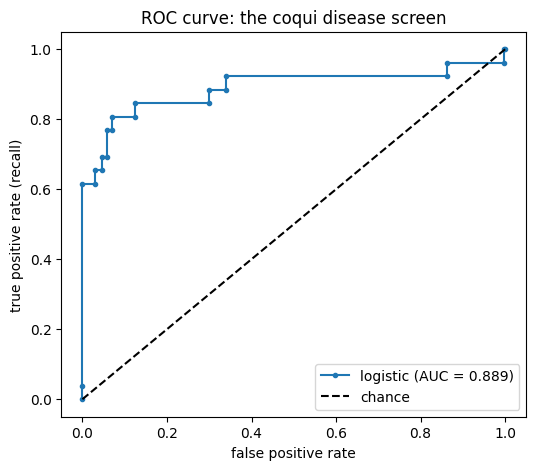

AUC: 0.889


In [6]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, marker=".", label=f"logistic (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="chance")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate (recall)")
ax.set_title("ROC curve: the coqui disease screen")
ax.legend(loc="lower right")
plt.show()

print(f"AUC: {auc:.3f}")

~~~text
AUC: 0.889
~~~

An AUC of **0.889** says the model ranks a random infected frog above a random healthy
one about 89% of the time -- genuinely better than the 0.5 of a coin flip, and a fairer
summary than the accuracy was. The curve bows toward the top-left corner; a useless
model would lie along the dashed diagonal.

## Your Turn

### Exercise 1 -- Pick the operating point

The team's rule: **catch at least 75% of infections** (recall >= 0.75). From the Step 3
sweep, choose the *highest* threshold that still clears that bar, and report the
precision you would be accepting.

**Hint:** scan the Step 3 table for the largest `thr` whose recall is at least 0.75, and read off its precision.

In [7]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
chosen threshold 0.2: recall 0.769 (>= 0.75), precision 0.556
~~~

At thr=0.2 the screen catches 76.9% of infections -- clearing the 75% bar -- at a
precision of 0.556, meaning a little over half of the frogs it flags are truly
infected. Whether that false-alarm rate is acceptable is a *cost* decision, not a
statistics one; the metrics just make the trade explicit.
</details>

### Exercise 2 -- Regression metrics

Metrics for a regression are different -- no confusion matrix, just how far predictions
miss. Fit a linear model on the small regression below and report MSE, RMSE, MAE, and
R-squared.

**Hint:** use `mean_squared_error`, `mean_absolute_error`, `r2_score`; RMSE is the square root of MSE.

In [8]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Xr, yr = make_regression(n_samples=200, n_features=5, n_informative=4, noise=15.0,
                         random_state=11)
Rtr, Rte, ytr_r, yte_r = train_test_split(Xr, yr, test_size=0.30, random_state=11)
reg = LinearRegression().fit(Rtr, ytr_r)
pred = reg.predict(Rte)

# TODO: your code here -- print MSE, RMSE, MAE, R2

<details><summary>Expected Output</summary>

~~~text
MSE: 248.5
RMSE: 15.76
MAE: 13.22
R2: 0.979
~~~

RMSE (15.76) is in the target's own units -- the headline "typical miss". MAE (13.22)
is a touch smaller because it does not square-amplify the larger errors. R-squared
(0.979) says the model explains about 98% of the variance, far above the
predict-the-mean baseline from L03. Different task, different metrics -- same habit of
never trusting a single number.
</details>

## Summary

- Accuracy lied: the all-healthy baseline scored 0.913 and the logistic model 0.943,
  yet the model caught only 9 of 26 infections (recall 0.346) -- on imbalanced data,
  accuracy rewards the majority class.
- The confusion matrix exposed the 17 misses; precision (1.000) and recall (0.346)
  asked the two questions accuracy could not, and F1 (0.514) refused to call it good.
- The decision threshold is a dial: dropping it from 0.5 to 0.1 raised recall from
  0.346 to 0.846 while precision fell from 1.000 to 0.250 -- you choose the operating
  point by what an error costs.
- ROC-AUC (0.889) summarized the model across all thresholds in one threshold-free
  number; regression uses MSE/RMSE/MAE/R-squared instead.
- This closes Unit III (learning theory). Next (L12, Unit IV): ensembles -- decision
  trees, bagging, and random forests, where many weak models vote into a strong one.